In [213]:
import sys
import os
sys.path.append(os.path.abspath(".."))


In [1]:
import yaml
import torch
import pandas as pd
from glob import glob
from lightning.pytorch import Trainer

from hippy2d.factory import get_model, get_datamodule
from hippy2d.models import InvNet    
# Mnist Rot Test
#model_dir = "/Users/karella/Projects/rotation-invariant-neural-networks/hippy2d/logs/csv/prototype-mnistrottest-k11/9c371ab193d3de8dec6b0145266aed8ba4230f72-24"
#model_dir = "/Users/karella/Projects/rotation-invariant-neural-networks/hippy2d/logs/csv/resnet18-baseline/1c07166a221a5fe083f8cf445d56606d435901c9-42"
# Histology 
#model_dir = "/Users/karella/Projects/rotation-invariant-neural-networks/hippy2d/logs/csv/prototype-histology-k15/15bcb8fd653b6bbc290ce02fb98cd17b3a76dca6-12"
model_dir = "/Users/karella/Projects/rotation-invariant-neural-networks/hippy2d/logs/csv/test_resnet.r160_in1k-histology/ef9183e8fba24a7aeba6082a6e7bc648b04ecc4a-42"
data_dir = "/Users/karella/Projects/rotation-invariant-neural-networks/hippy2d/data"
model_weights_path = glob(f"{model_dir}/checkpoints/*.ckpt")
df = pd.read_csv(f"{model_dir}/metrics.csv")
# Get test accuracy
assert len(df['test_acc'].dropna()) == 1
test_accuracy = df['test_acc'].dropna().values[0]
assert len(model_weights_path) == 1, "Expected exactly one checkpoint file"
model_weights_path = model_weights_path[0]
h_params_path = f"{model_dir}/hparams.yaml"
assert os.path.exists(h_params_path)

with open(h_params_path, 'r') as f:
    h_params = yaml.safe_load(f)

dataset_name = h_params['dataset_name']
d_hparams = h_params['d_hparams']
m_param = h_params['m_param']
model_name = h_params['model_name']

d_hparams['data_dir'] = data_dir


# Create the model 
print(f"Using dataset: {dataset_name} with parameters: {d_hparams}")
datamodule = get_datamodule(dataset_name, d_hparams)
print(f"Using model: {model_name} with parameters: {m_param}")
model = get_model(model_name, m_param)

# Load best model
best_model = InvNet(input_shape=datamodule.output_shape,
                    model=model) 

best_checkpoint = torch.load(model_weights_path, 
                             weights_only=False, 
                             map_location='cpu')
_result = best_model.load_state_dict(best_checkpoint['state_dict'], strict=True)
print(_result)
best_model.eval()
best_model.freeze()

trainer = Trainer()
results = trainer.test(best_model, datamodule=datamodule)
torch.testing.assert_close(test_accuracy,  results[0]['test_acc'])

ModuleNotFoundError: No module named 'hippy2d'

In [253]:
device = torch.device("mps")
best_model.to(device)
# Run the loop manually
for idx, batch in enumerate(datamodule.test_dataloader()):
    x, y = batch
    rot_90_images = torch.rot90(x, k=1, dims=[-2, -1]).to(device)
    rot_180_images = torch.rot90(x, k=2, dims=[-2, -1]).to(device)
    rot_270_images = torch.rot90(x, k=3, dims=[-2, -1]).to(device)
    with torch.no_grad():
        x = x.to(device)
        y_hat = best_model(x)
        y_hat_rot_90 = best_model(rot_90_images)
        y_hat_rot_180 = best_model(rot_180_images)
        y_hat_rot_270 = best_model(rot_270_images)
    if idx == 0:
        all_y = y
        all_yhat = y_hat
        all_yhat_rot_90 = y_hat_rot_90
        all_yhat_rot_180 = y_hat_rot_180
        all_yhat_rot_270 = y_hat_rot_270
    else:
        all_y = torch.cat((all_y, y), dim=0)
        all_yhat = torch.cat((all_yhat, y_hat), dim=0)
        all_yhat_rot_90 = torch.cat((all_yhat_rot_90, y_hat_rot_90), dim=0)
        all_yhat_rot_180 = torch.cat((all_yhat_rot_180, y_hat_rot_180), dim=0)
        all_yhat_rot_270 = torch.cat((all_yhat_rot_270, y_hat_rot_270), dim=0)

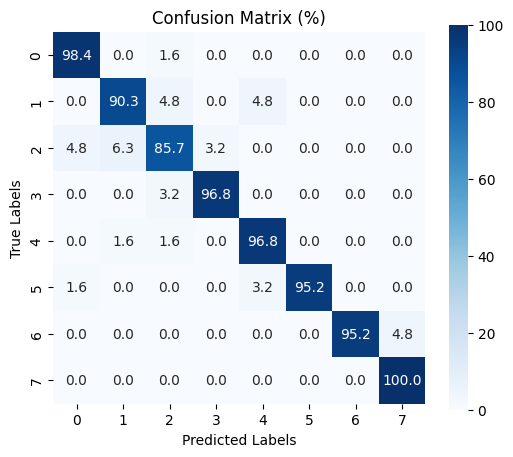

In [254]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Convert torch tensors to numpy
y_true = all_y.cpu().numpy()
y_pred = all_yhat.argmax(dim=1).cpu().numpy()

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Normalize to percentages
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

# Plot normalized confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_normalized, 
            annot=True,
            fmt=".1f",
            cmap="Blues",
            xticklabels=np.unique(y_true),
            yticklabels=np.unique(y_true),
            square=True)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix (%)")
plt.show()

In [255]:
from sklearn.metrics import accuracy_score
from torch.nn import functional as F
samples = torch.stack([all_yhat_rot_90, all_yhat_rot_180, all_yhat_rot_270], dim=1)


norm = torch.norm(samples - all_yhat[:, None], dim=-1)  # Shape: (N, 3)
print(f"L2-Norm {norm.mean()} +- {norm.std()}")

cos_sim = F.cosine_similarity(samples, all_yhat[:, None], dim=-1)  # Shape: (N, 3)
cos_mean = cos_sim.mean()
cos_std = cos_sim.std()
print(f"Cosine Similarity {cos_mean} +- {cos_std}")

# Accuracy per each
pred_samples = samples.argmax(dim=-1)  # Shape: (N, 3)
orig_acc = accuracy_score(all_y.cpu().numpy(), pred_samples[:, 0].cpu().numpy())
print(f"Rotation 0 - Accuracy: {orig_acc}")
for i, rot in enumerate([90, 180, 270]):
    acc = accuracy_score(all_y.cpu().numpy(), pred_samples[:, i].cpu().numpy())
    print(f"Rotation {rot} - Accuracy: {acc} ({acc - orig_acc})")


L2-Norm 1.8824176788330078 +- 1.2418321371078491
Cosine Similarity 0.9886537790298462 +- 0.02124842256307602
Rotation 0 - Accuracy: 0.918
Rotation 90 - Accuracy: 0.918 (0.0)
Rotation 180 - Accuracy: 0.934 (0.016000000000000014)
Rotation 270 - Accuracy: 0.912 (-0.006000000000000005)


In [223]:
import torch.nn.functional as F
from torch.autograd.functional import jvp

def rotate(imgs, theta):
    """ Rotate images by angle theta and interpolate"""
    m = [[torch.cos(theta), torch.sin(theta), 0],
         [-torch.sin(theta), torch.cos(theta), 0]]
    m = torch.tensor(m)[None].expand(imgs.shape[0], -1, -1).to(device)
    return F.grid_sample(imgs, F.affine_grid(m, imgs.size(), True))

def rotation_lie_deriv(model,imgs):
    """ Lie deriv. of model w.r.t. rotation, can be scalar/image"""
    def rotated_model(theta):
        z = model(rotate(imgs,theta))
        img_like = (len(z.shape) == 4) # more complex for ViT/Mixer
        return rotate(z,-theta) if img_like else z
    return jvp(rotated_model, torch.zeros(1,requires_grad=True))[-1]

def e_lee(model,imgs):
    """ Expected equiv. error (E[|Lf|^2]/d_out) w.r.t. rotation"""
    return rotation_lie_deriv(model, imgs)

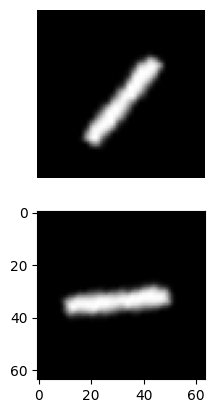

In [234]:
# Show batch
plt.subplot(211)
plt.imshow(batch[0][0].squeeze(), cmap='gray')
plt.axis('off')
rotated = rotate(batch[0].to(device), torch.tensor(torch.pi/4))
plt.subplot(212)
plt.imshow(rotated[0].squeeze().cpu(), cmap='gray')

In [257]:
# load the model again 
model = get_model(model_name, m_param)
best_model = InvNet(input_shape=datamodule.output_shape,
                    model=model) 
print(best_model.load_state_dict(best_checkpoint['state_dict'], strict=True))


<All keys matched successfully>
